<a href="https://colab.research.google.com/github/ismael-almazan/PNL/blob/main/NER__ISMAEL_ALMAZAN_PNL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Maestría en Inteligencia Artificial y Analítica de Datos<h1>
<h2>Procesamiento de Lenguaje Natural<h2>
<h2> Tarea: Reconocimiento de Entidades Nombradas <h2>
<h3>Estudiante: Ismael Almazan Luna<h3>
Fecha : 21 de mayo de 2026

# LIbrerias Requeridas

In [8]:
!pip install sklearn-crfsuite seqeval --quiet

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from collections import Counter
import pandas as pd

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.5 MB/s eta 0:00:00


## 1. Carga del conjunto de datos

In [14]:

# Cargar del los datos desde Google Drive
df = pd.read_csv('/content/drive/MyDrive/ClassFiles/PNL/split1.mx-news (1).txt', sep='\t')
print(df.shape)
print(df['Tag'].value_counts())
df.head(10)

(49318, 4)
Tag
O        39246
B-PER      785
E-PER      785
I-ORG      632
I-TIT      518
         ...  
S-FAC       11
S-PRO        6
S-EVT        5
I-AGE        4
S-LOC        1
Name: count, Length: 63, dtype: int64


,Sentence #,Word,Pos,Tag
0,Sentence 1,Interesante,ADJ,O
1,Sentence 1,será,VLfin,O
2,Sentence 1,conocer,VLinf,O
3,Sentence 1,las,ART,O
4,Sentence 1,reflexiones,NC,O
5,Sentence 1,de,PREP,O
6,Sentence 1,Pedro,NP,B-PER
7,Sentence 1,Kumamoto,NC,E-PER
8,Sentence 1,en,PREP,O
9,Sentence 1,torno,NC,O


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Preprocesamiento - generar frases


In [4]:
# Funcion para agupar
def agrupar_oraciones(df):
    oraciones = []
    grouped = df.groupby('Sentence #', sort=False)
    for _, grupo in grouped:
        sentence = [(w, p, t) for w, p, t in zip(grupo['Word'], grupo['Pos'], grupo['Tag'])]
        oraciones.append(sentence)
    return oraciones

sentences = agrupar_oraciones(df)
print(sentences[0])

[('Interesante', 'ADJ', 'O'), ('será', 'VLfin', 'O'), ('conocer', 'VLinf', 'O'), ('las', 'ART', 'O'), ('reflexiones', 'NC', 'O'), ('de', 'PREP', 'O'), ('Pedro', 'NP', 'B-PER'), ('Kumamoto', 'NC', 'E-PER'), ('en', 'PREP', 'O'), ('torno', 'NC', 'O'), ('a', 'PREP', 'O'), ('este', 'DM', 'O'), ('fracaso', 'NC', 'O'), (',', 'CM', 'O'), ('por', 'PREP', 'O'), ('el', 'ART', 'O'), ('momento', 'NC', 'O'), ('lo', 'ART', 'O'), ('único', 'NC', 'O'), ('que', 'CQUE', 'O'), ('ha', 'VHfin', 'O'), ('dicho', 'QU', 'O'), ('es', 'VSfin', 'O'), ('que', 'CQUE', 'O'), ('al', 'PAL', 'O'), ('interior', 'NC', 'O'), ('de', 'PREP', 'O'), ('su', 'PPO', 'O'), ('grupo', 'NC', 'O'), ('existen', 'VLfin', 'O'), ('dos', 'CARD', 'O'), ('planteamientos', 'NC', 'O'), (',', 'CM', 'O'), ('uno', 'CARD', 'O'), ('seguir', 'VLinf', 'O'), ('por', 'PREP', 'O'), ('la', 'ART', 'O'), ('ruta', 'NC', 'O'), ('independiente', 'ADJ', 'O'), (',', 'CM', 'O'), ('el', 'ART', 'O'), ('otro', 'QU', 'O'), ('destaca', 'VLfin', 'O'), ('las', 'ART', '

## 3. Conjuntos train (80%) y test (20%)

In [5]:
from sklearn.model_selection import train_test_split

train_sents, test_sents = train_test_split(sentences, test_size=0.20, random_state=42)
print(f'Train: {len(train_sents)} oraciones')
print(f'Test : {len(test_sents)} oraciones')

Train: 1036 oraciones
Test : 259 oraciones


## 4. Extraccion de caracteristicas

In [15]:
def word2features(sent, i):
    word, pos, _ = sent[i]
    features = {
        'bias'         : 1.0,
        'word.lower()' : word.lower(),
        'postag'       : pos,
        'postag[:2]'   : pos[:2],
        'is_title'     : word.istitle(),
        'is_upper'     : word.isupper(),
        'is_digit'     : word.isdigit(),
        'word[-3:]'    : word[-3:],
        'word[-2:]'    : word[-2:],
    }
    if i > 0:
        w1, p1, _ = sent[i - 1]
        features.update({'-1:word.lower()': w1.lower(), '-1:postag': p1})
    else:
        features['BOS'] = True
    if i < len(sent) - 1:
        w1, p1, _ = sent[i + 1]
        features.update({'+1:word.lower()': w1.lower(), '+1:postag': p1})
    else:
        features['EOS'] = True
    return features

def sent2features(sent):
    return [word2features(sent, i) for i in range(len(sent))]

def sent2labels(sent):
    return [tag for _, _, tag in sent]

X_train = [sent2features(s) for s in train_sents]
y_train = [sent2labels(s)   for s in train_sents]
X_test  = [sent2features(s) for s in test_sents]
y_test  = [sent2labels(s)   for s in test_sents]

## 5. Entrenamiento del modelo CRF

In [9]:
import sklearn_crfsuite

#Modelo
crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.1,
    c2=0.1,
    max_iterations=100,
    all_possible_transitions=True
)
crf.fit(X_train, y_train)
print('Modelo entrenado.')

Modelo entrenado.


## 6. Métricas de desempeño

In [10]:
from sklearn_crfsuite import metrics

y_pred = crf.predict(X_test)

labels = sorted(set(t for s in y_test for t in s) - {'O'})

print(metrics.flat_classification_report(y_test, y_pred, labels=labels, digits=3))

              precision    recall  f1-score   support

       B-ADD      1.000     0.857     0.923         7
       B-AGE      1.000     1.000     1.000         5
       B-DAT      0.981     0.954     0.967       109
       B-DOC      0.900     0.643     0.750        14
       B-EVT      0.857     0.522     0.649        23
       B-FAC      0.800     0.571     0.667        14
       B-GPE      0.870     0.741     0.800        27
       B-LOC      1.000     0.250     0.400         4
       B-MNY      1.000     0.769     0.870        13
       B-ORG      0.843     0.875     0.859        80
       B-PER      0.914     0.946     0.930       147
       B-PEX      1.000     1.000     1.000        13
       B-PRC      1.000     1.000     1.000        12
       B-PRO      1.000     0.333     0.500         3
       B-TIM      1.000     0.837     0.911        49
       B-TIT      0.780     0.727     0.753        44
       E-ADD      1.000     0.857     0.923         7
       E-AGE      1.000    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
from seqeval.metrics import classification_report

print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

         ADD       1.00      0.71      0.83        14
         AGE       1.00      1.00      1.00         5
         DAT       0.96      0.94      0.95       195
         DEM       0.92      0.57      0.71        21
         DOC       0.93      0.74      0.82        19
         EVT       0.86      0.52      0.65        23
         FAC       0.64      0.41      0.50        17
         GPE       0.86      0.75      0.80       114
         LOC       1.00      0.20      0.33         5
         MNY       1.00      0.77      0.87        13
         ORG       0.82      0.75      0.79       149
         PER       0.88      0.88      0.88       184
         PEX       0.95      0.93      0.94        43
         PRC       1.00      1.00      1.00        12
         PRO       1.00      0.25      0.40         4
         TIM       1.00      0.81      0.90        53
         TIT       0.74      0.64      0.69        72

   micro avg       0.89   

## 7. Matriz de confusión

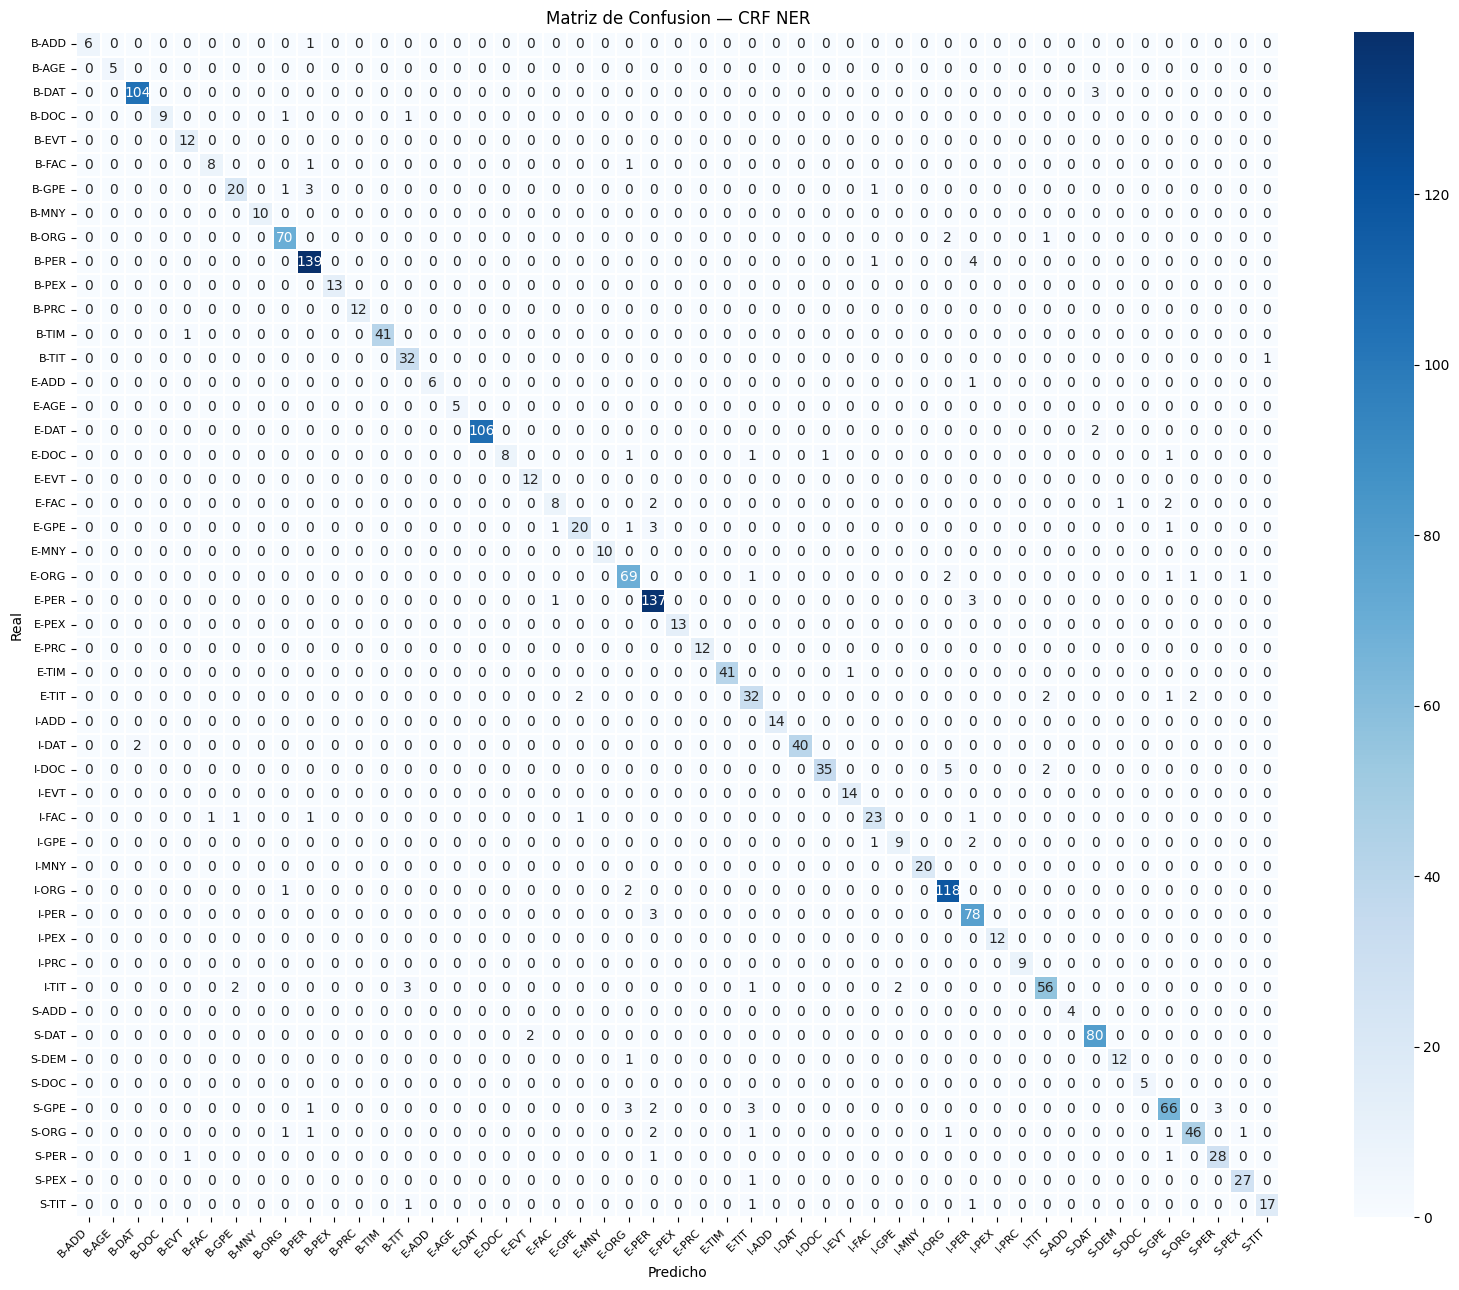

In [12]:
#
y_test_flat = [t for s in y_test for t in s]
y_pred_flat = [t for s in y_pred for t in s]

# Solo etiquetas con soporte >= 5 para mejor visualiacion
counts    = Counter(y_test_flat)
lbs       = sorted([t for t, c in counts.items() if c >= 5 and t != 'O'])
pairs     = [(t, p) for t, p in zip(y_test_flat, y_pred_flat) if t in lbs]
yt        = [p[0] for p in pairs]
yp        = [p[1] for p in pairs]
all_lbs   = sorted(set(yt) | (set(yp) & set(lbs)))

cm = confusion_matrix(yt, yp, labels=all_lbs)

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=all_lbs, yticklabels=all_lbs, linewidths=0.3, ax=ax)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusion — CRF NER')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## 8. Etiqueta con menor desempeño

In [13]:
from sklearn.metrics import classification_report as skr

report = skr(y_test_flat, y_pred_flat, labels=labels, zero_division=0, output_dict=True)

rows = [
    {'etiqueta': lbl, 'f1': round(m['f1-score'], 3), 'soporte': int(m['support'])}
    for lbl, m in report.items()
    if isinstance(m, dict) and lbl not in ('accuracy','macro avg','weighted avg')
]

import pandas as pd
df_res = pd.DataFrame(rows).sort_values('f1')
peor   = df_res[df_res['soporte'] > 0].iloc[0]

print(df_res[df_res['soporte'] > 0].to_string(index=False))
print()
print(f'Etiqueta con menor F1: {peor["etiqueta"]}  (F1={peor["f1"]}, soporte={peor["soporte"]})')

 etiqueta    f1  soporte
    S-FAC 0.000        3
    S-LOC 0.000        1
    S-PRO 0.000        1
    I-PRO 0.000        1
    B-LOC 0.400        4
    E-LOC 0.400        4
    E-PRO 0.500        3
    B-PRO 0.500        3
    I-FAC 0.622       37
    B-EVT 0.649       23
    E-EVT 0.649       23
    S-TIM 0.667        4
    E-FAC 0.667       14
    I-LOC 0.667        4
    B-FAC 0.667       14
    E-DOC 0.696       14
    S-DEM 0.706       21
    I-TIT 0.713       80
    S-ADD 0.727        7
    E-TIT 0.727       44
    S-TIT 0.739       28
    B-DOC 0.750       14
    B-TIT 0.753       44
    S-ORG 0.754       69
    I-DOC 0.778       52
    I-GPE 0.783       12
    B-GPE 0.800       27
    I-EVT 0.800       19
    E-GPE 0.800       27
    S-GPE 0.805       87
    S-PER 0.824       37
    E-ORG 0.847       80
    I-TIM 0.857        4
    B-ORG 0.859       80
micro avg 0.859     2034
    I-ORG 0.864      131
    I-MNY 0.870       26
    E-MNY 0.870       13
    B-MNY 0.870       13


## **RESULTADO **


Analisis:
  La etiqueta S-FAC tuvo el F1-Score mas bajo (0.0).
  Esto se debe principalmente a su baja frecuencia en el corpus,
  lo que limita los ejemplos de entrenamiento disponibles para el modelo.
  Ademas, este tipo de entidad puede presentar ambiguedad lexica con
  otras categorias, dificultando la clasificacion basada en contexto local.